In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\ngc346_MUSE\py_modules")
sys.path.append(r"C:\Users\ZAINTEL2\Dropbox\GitHub\ngc346_MUSE")

from rebin_utils import downsample

# NGC 346 Data

In [3]:
# Data from observations

inst = 'MUSE'
pix  = 0.2 #arcsec
dist = 62000 #parsecs
pc   = dist*(2*np.pi) / (360 * 60 * 60)
s0   = (0.9*pc)
pc , s0

(0.3005844822879123, 0.27052603405912107)

# [SII]

In [4]:
name =  "MUSE-N346-S"
line = "S_II-"

In [5]:
_data = json.load(open('observations/'+ name + '-m.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
ss    = np.array(_data['ss'])

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_17964\2269846735.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


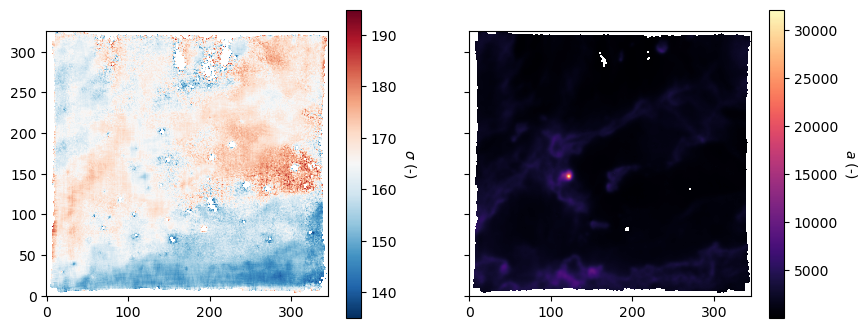

In [6]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [7]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)
#m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 3

good = (~m) & (sb > 1e-3) & (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))

In [8]:
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
ss_m = np.where(good, ss, np.nan)   

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_17964\2908207673.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


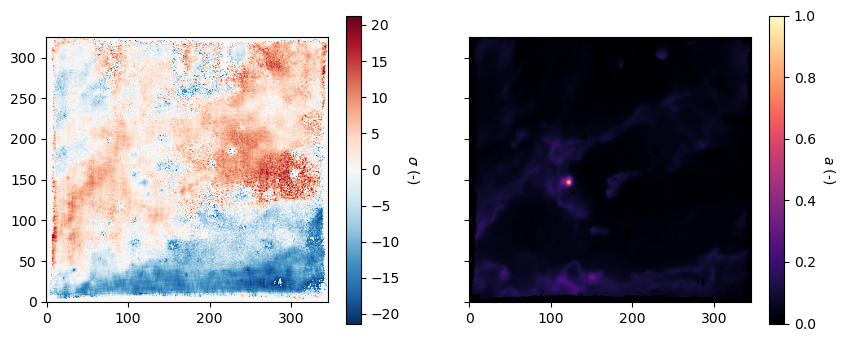

In [9]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [10]:
trim = (slice(20, 315), slice(10, 330))
trim

(slice(20, 315, None), slice(10, 330, None))

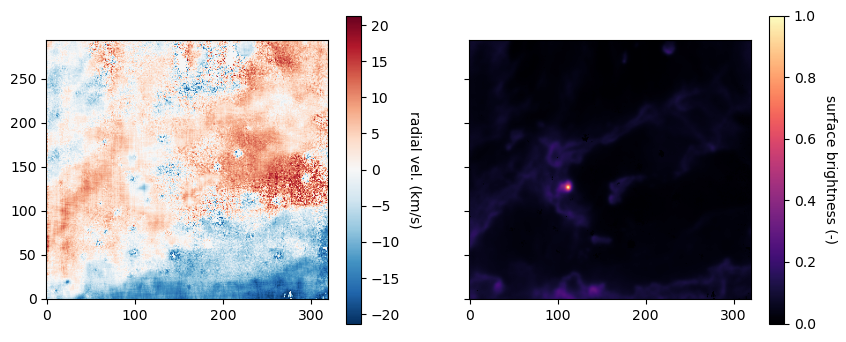

In [11]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)

In [12]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

18.470665744008677

In [13]:
sig = np.nanstd(vv_m[trim])
sig

6.721591733124812

# Downsample

In [14]:
prod_map  = sb * vv
sb_       = pd.notna(sb)
vv_       = pd.notna(vv)
prod_map_ = sb_ * vv_

In [15]:
bins = 2
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [sb], sb_= downsample([sb], sb_, mingood=mingood)

for mingood in zip(mingoods):
 [prod_map], prod_map_= downsample([prod_map], prod_map_, mingood=mingood)

# Velocity binned map
vv = prod_map/sb

C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_17964\3109779331.py:11: RuntimeWarning: invalid value encountered in divide
  vv = prod_map/sb


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_17964\2269846735.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


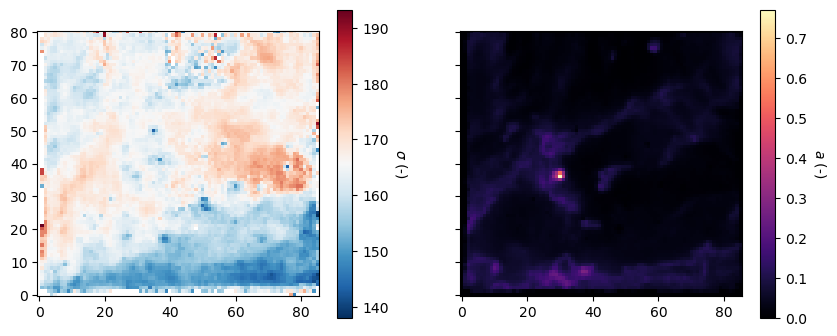

In [16]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [17]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv) | (sb < 0.0)
#m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
#ss[m] = 0.0
sb /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 3

good = (~m) & (sb > 1e-3) & (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))

In [18]:
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
#ss_m = np.where(good, ss, np.nan)   

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_17964\2908207673.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


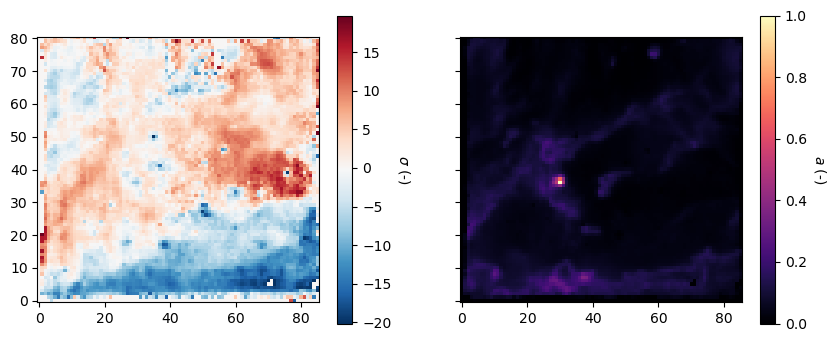

In [19]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [20]:
trim = (slice(int(20/2**bins), int(315/2**bins)), slice(int(10/2**bins), int(330/2**bins)))

In [21]:
trim

(slice(5, 78, None), slice(2, 82, None))

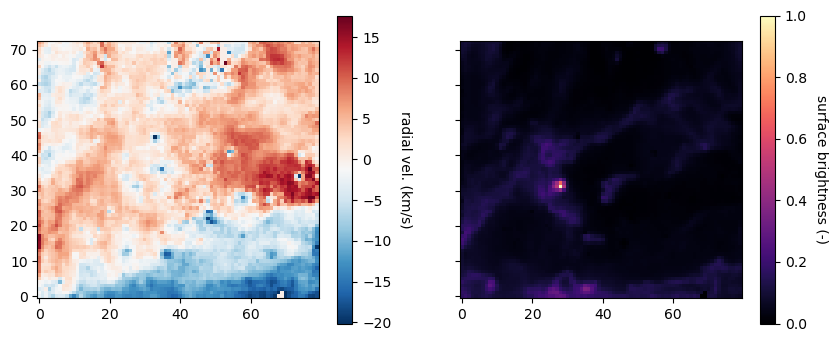

In [22]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)

In [23]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

4.59412677663552

In [24]:
sig = np.nanstd(vv_m[trim])
sig

6.264709796453616

# Export

In [25]:
hdr = fits.Header()
hdr["INSTR"]      = inst
hdr["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
hdr["sig"]        = (sig, "Standard deviation vel map")
hdr["sig2"]       = (sig**2, "Vel Variance map")
hdr["s0"]         = (s0, "Atmospheric seeing")
#hdr["noise"]     = (noise, "Instrumental noise")
hdr["box_size"]   = (N, "Observational box_size")
hdr["pc"]         = (pc, "parsec convertion")
hdr["pix"]        = (pix, "Instrument pixel scale")
hdr["LINE"]       = (line, "Emission line name")
hdr["BINSIZE"]    = (bins, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

primary_hdu = fits.PrimaryHDU(header=hdr)
hdu_m0 = fits.ImageHDU(data=sb_m[trim],  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m[trim],  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')



In [26]:
hdul = fits.HDUList([primary_hdu, hdu_m0, hdu_m1])
hdul.writeto('fits_ready/' + name + '_bin' + str(bins) + '.fits', overwrite=True)